## Подготовка

### Импорты, seed и устройство

In [ ]:
import os
import json
import math
import time
import random
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torchvision.datasets import Flowers102, VOCDetection, wrap_dataset_for_transforms_v2

from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "./data"

BATCH_SIZE = 128

Device: cuda


In [3]:
os.makedirs("artifacts/figures/", exist_ok=True)

### Данные и DataLoader

#### Часть A

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [5]:
tf_train_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tf_train_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tf_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ds_train_base = Flowers102(root=DATA_DIR, split="train", download=True, transform=tf_train_base)
ds_train_aug = Flowers102(root=DATA_DIR, split="train", download=True, transform=tf_train_aug)
ds_val = Flowers102(root=DATA_DIR, split="val", download=True, transform=tf_test)
ds_test = Flowers102(root=DATA_DIR, split="test", download=True, transform=tf_test)

class_names = ds_train_base.classes
print("Train:", len(ds_train_base))
print("Validation:", len(ds_val))
print("Test:", len(ds_test))
print("CLasses:", class_names)

100%|██████████| 345M/345M [00:18<00:00, 19.0MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.12MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 43.3MB/s]


Train: 1020
Validation: 1020
Test: 6149
CLasses: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geran

In [6]:
train_base_loader = DataLoader(ds_train_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_aug_loader = DataLoader(ds_train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [7]:
batch = next(iter(train_base_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([128, 3, 224, 224]) torch.float32
y: torch.Size([128]) torch.int64


In [8]:
def denorm_images(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return x * std + mean

In [9]:
@torch.no_grad()
def show_images(loader, n: int = 10, filepath: str = "") -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_images(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")

    if filepath != "":
        plt.savefig(filepath, dpi=150, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

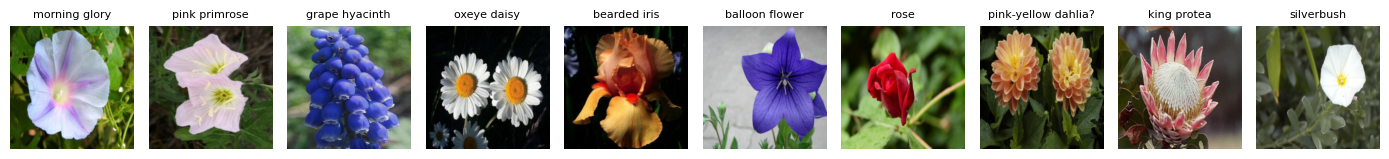

In [10]:
show_images(train_base_loader, n=10)

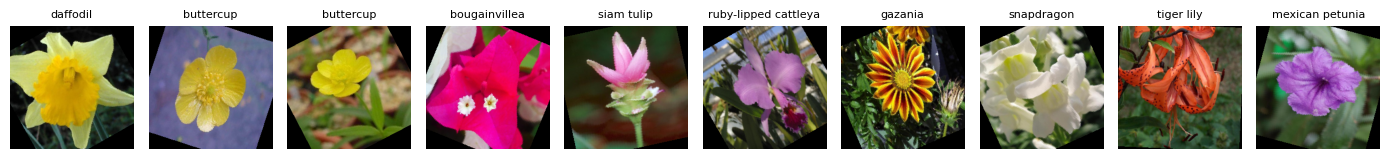

In [11]:
show_images(train_aug_loader, n=10, filepath="artifacts/figures/augmentations_preview.png")

#### Часть B

In [12]:
voc_transform = transforms.Compose([
    transforms.ToTensor(),
])

voc_dataset = VOCDetection(root=DATA_DIR, image_set="val", download=True, transform=voc_transform)
voc_dataset = wrap_dataset_for_transforms_v2(voc_dataset)

print("Validation:", len(voc_dataset))

100%|██████████| 2.00G/2.00G [01:11<00:00, 28.0MB/s]


Validation: 5823


In [13]:
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag',
    'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite',
    'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock',
    'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

VOC_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

VOC_TO_COCO_NAME = {
    'aeroplane': 'airplane',
    'bicycle': 'bicycle',
    'bird': 'bird',
    'boat': 'boat',
    'bottle': 'bottle',
    'bus': 'bus',
    'car': 'car',
    'cat': 'cat',
    'chair': 'chair',
    'cow': 'cow',
    'diningtable': 'dining table',
    'dog': 'dog',
    'horse': 'horse',
    'motorbike': 'motorcycle',
    'person': 'person',
    'pottedplant': 'potted plant',
    'sheep': 'sheep',
    'sofa': 'couch',
    'train': 'train',
    'tvmonitor': 'tv'
}

COCO_IDX_TO_VOC_IDX = {}
for voc_idx, voc_name in enumerate(VOC_CLASSES):
    if voc_name == '__background__':
        continue
    coco_name = VOC_TO_COCO_NAME.get(voc_name)
    if coco_name and coco_name in COCO_CLASSES:
        coco_idx = COCO_CLASSES.index(coco_name)
        COCO_IDX_TO_VOC_IDX[coco_idx] = voc_idx

In [ ]:
@torch.no_grad()
def show_images_with_bboxes(
    dataset,
    n: int = 5,
    filepath: str = "",
    use_voc_classes: bool = True
) -> None:
    plt.figure(figsize=(15, 5))

    for i in range(n):
        image, target = dataset[i]

        image = image.clamp(0, 1).permute(1, 2, 0).numpy()

        plt.subplot(1, n, i + 1)
        plt.imshow(image)

        boxes = target.get('boxes', torch.empty((0, 4)))
        labels = target.get('labels', torch.empty((0,), dtype=torch.int64))

        if len(boxes) > 0:
            for j, (box, label) in enumerate(zip(boxes, labels)):
                x1, y1, x2, y2 = box.cpu().numpy()
                xmin, ymin = int(x1), int(y1)
                xmax, ymax = int(x2), int(y2)

                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=1.5,
                    edgecolor='r',
                    facecolor='none'
                )
                plt.gca().add_patch(rect)

                if use_voc_classes:
                    class_idx = label.item()
                    if 0 <= class_idx < len(VOC_CLASSES):
                        class_name = VOC_CLASSES[class_idx]
                    else:
                        class_name = f'class_{class_idx}'
                else:
                    class_name = f'{label.item()}'

                plt.text(
                    xmin,
                    ymin - 5,
                    class_name,
                    fontsize=8,
                    color='red',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7)
                )

        plt.title(f"Image {i+1} ({len(boxes)} objects)", fontsize=10)
        plt.axis("off")

    if filepath != "":
        plt.savefig(filepath, dpi=150, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

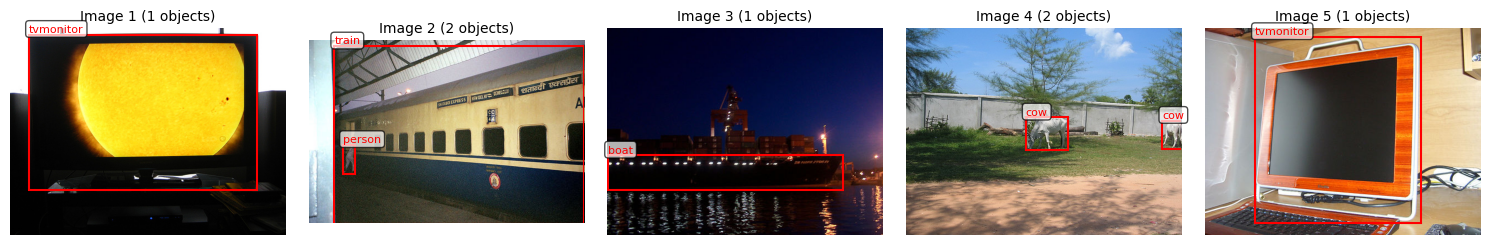

In [15]:
show_images_with_bboxes(voc_dataset, n=5, filepath="artifacts/figures/detection_examples.png")

### Базовые функции обучения и оценки

#### Часть A

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {train_loss:.4f}, acc {train_acc:.3f} | "
                f"val loss {val_loss:.4f}, acc {val_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(train_loss)) or (not math.isfinite(val_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    history["best_val_acc"] = best_val_acc

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, model

In [34]:
def plot_history(history: Dict[str, List[float]], title: str = "", filepath: str = "") -> None:
    epochs = list(range(1, len(history["train_loss"]) + 1))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(epochs, history["train_loss"], label="train loss")
    ax1.plot(epochs, history["val_loss"], label="val loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax1.set_title(title + " | loss")
    ax1.grid(True)
    ax1.legend()

    ax2.plot(epochs, history["train_acc"], label="train acc")
    ax2.plot(epochs, history["val_acc"], label="val acc")
    ax2.set_xlabel("epoch")
    ax2.set_ylabel("accuracy")
    ax2.set_title(title + " | accuracy")
    ax2.grid(True)
    ax2.legend()

    if filepath != "":
        plt.savefig(filepath, dpi=150, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

#### Часть B

In [18]:
def get_ground_truth(target, idx):
    gt_boxes = target['boxes'].to(DEVICE)
    gt_labels = target['labels'].to(DEVICE)
    return gt_boxes, gt_labels


def convert_coco_label_to_voc(coco_label: int) -> int:
    return COCO_IDX_TO_VOC_IDX.get(coco_label.item(), -1)

In [19]:
def calculate_iou(box1: torch.Tensor, box2: torch.Tensor) -> float:
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    if union == 0:
        return 0.0
    return intersection / union


def calculate_iou_matrix(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor) -> np.ndarray:
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return np.zeros((len(pred_boxes), len(gt_boxes)))

    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)))
    for i, pred_box in enumerate(pred_boxes):
        for j, gt_box in enumerate(gt_boxes):
            iou_matrix[i, j] = calculate_iou(pred_box, gt_box)
    return iou_matrix

In [20]:
def match_predictions_to_ground_truth(
    pred_boxes: torch.Tensor,
    pred_labels: torch.Tensor,
    pred_scores: torch.Tensor,
    gt_boxes: torch.Tensor,
    gt_labels: torch.Tensor,
    iou_threshold: float = 0.5
) -> Dict:
    num_pred = len(pred_boxes)
    num_gt = len(gt_boxes)

    if num_pred == 0 and num_gt == 0:
        return {'tp': 0, 'fp': 0, 'fn': 0, 'matched_ious': [], 'matched_pairs': []}

    if num_pred == 0:
        return {'tp': 0, 'fp': 0, 'fn': num_gt, 'matched_ious': [], 'matched_pairs': []}

    if num_gt == 0:
        return {'tp': 0, 'fp': num_pred, 'fn': 0, 'matched_ious': [], 'matched_pairs': []}

    iou_matrix = calculate_iou_matrix(pred_boxes, gt_boxes)

    pred_matched = np.zeros(num_pred, dtype=bool)
    gt_matched = np.zeros(num_gt, dtype=bool)

    matched_ious = []
    matched_pairs = []

    while True:
        max_iou = iou_matrix.max()
        if max_iou < iou_threshold:
            break

        pred_idx, gt_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)

        pred_voc_label = convert_coco_label_to_voc(pred_labels[pred_idx])
        gt_voc_label = gt_labels[gt_idx].item()

        if pred_voc_label == gt_voc_label and pred_voc_label != -1:
            pred_matched[pred_idx] = True
            gt_matched[gt_idx] = True
            matched_ious.append(max_iou)
            matched_pairs.append((pred_idx, gt_idx, max_iou))

        iou_matrix[pred_idx, :] = -1
        iou_matrix[:, gt_idx] = -1

    tp = np.sum(pred_matched)
    fp = num_pred - tp
    fn = num_gt - np.sum(gt_matched)

    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'matched_ious': matched_ious,
        'matched_pairs': matched_pairs
    }

In [21]:
def run_inference(image: torch.Tensor, model: torch.nn.Module, score_threshold: float = 0.5) -> Dict[str, torch.Tensor]:
    image = image.to(DEVICE)
    with torch.no_grad():
        prediction = model([image])[0]

    mask = prediction['scores'] >= score_threshold
    return {
        'boxes': prediction['boxes'][mask],
        'labels': prediction['labels'][mask],
        'scores': prediction['scores'][mask]
    }

In [22]:
def calculate_metrics(all_results: List[Dict]) -> Dict[str, float]:
    total_tp = sum(r['tp'] for r in all_results)
    total_fp = sum(r['fp'] for r in all_results)
    total_fn = sum(r['fn'] for r in all_results)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    all_matched_ious = []
    for r in all_results:
        all_matched_ious.extend(r['matched_ious'])

    mean_iou = np.mean(all_matched_ious) if len(all_matched_ious) > 0 else 0.0

    return {
        'precision': precision, 'recall': recall, 'f1': f1, 'mean_iou': mean_iou,
        'total_tp': total_tp, 'total_fp': total_fp, 'total_fn': total_fn,
        'num_matched_pairs': len(all_matched_ious)
    }

In [23]:
def visualize_detections(
    image: torch.Tensor,
    pred_boxes: torch.Tensor,
    pred_labels: torch.Tensor,
    pred_scores: torch.Tensor,
    gt_boxes: torch.Tensor,
    gt_labels: torch.Tensor,
    class_names: Optional[List[str]] = None,
    score_threshold: float = 0.5,
    figsize: tuple = (6, 4),
    show_scores: bool = True
):
    image = image.cpu().numpy()

    if image.ndim == 3 and image.shape[0] in [1, 3]:
        image = np.transpose(image, (1, 2, 0))

    image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image

    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image)
    ax.axis('off')

    pred_color = '#FF0000'
    gt_color = '#00FF00'

    if len(pred_boxes) > 0:
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if score < score_threshold:
                continue

            box = box.cpu().numpy()
            x_min, y_min, x_max, y_max = box[:4]

            class_name = class_names[label.item()] if class_names and label is not None else f'Class {label.item()}'
            label_text = f'{class_name}: {score:.2f}' if show_scores else class_name

            rect = patches.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2,
                edgecolor=pred_color,
                facecolor='none',
                label='Prediction'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, label_text, color=pred_color, fontsize=8, weight='bold')

    if len(gt_boxes) > 0:
        for box, label in zip(gt_boxes, gt_labels):
            box = box.cpu().numpy()
            x_min, y_min, x_max, y_max = box[:4]

            class_name = class_names[label.item()] if class_names and label is not None else f'Class {label.item()}'
            label_text = f'GT: {class_name}'

            rect = patches.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--',
                label='Ground Truth'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, label_text, color=gt_color, fontsize=8, weight='bold')

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        unique_handles, unique_labels = [], []
        for h, l in zip(handles, labels):
            if l not in unique_labels:
                unique_handles.append(h)
                unique_labels.append(l)
        ax.legend(unique_handles, unique_labels, loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

In [24]:
def run_evaluation(score_threshold: float, num_images: int = 100, num_images_display: int = 5):
    all_results = []
    visualized_count = 0

    for idx in range(min(num_images, len(voc_dataset))):
        image, target = voc_dataset[idx]

        prediction = run_inference(image, model, score_threshold=score_threshold)

        gt_boxes, gt_labels = get_ground_truth(target, idx)

        match_result = match_predictions_to_ground_truth(
            pred_boxes=prediction['boxes'],
            pred_labels=prediction['labels'],
            pred_scores=prediction['scores'],
            gt_boxes=gt_boxes,
            gt_labels=gt_labels,
            iou_threshold=0.5
        )

        all_results.append(match_result)

        if idx < num_images_display:
            visualize_detections(
                image=image,
                pred_boxes=prediction['boxes'],
                pred_labels=prediction['labels'],
                pred_scores=prediction['scores'],
                gt_boxes=gt_boxes,
                gt_labels=gt_labels,
                class_names=None,
                score_threshold=0.5
            )

    metrics = calculate_metrics(all_results)

    return metrics

## Эксперименты

### Часть A: классификация, аугментации и transfer learning

In [35]:
NUM_CLASSES = len(class_names)

criterion = nn.CrossEntropyLoss()

In [36]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [37]:
def run_experiment(exp_id: str, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, lr: float = 1e-3, epochs: int = 10, params = None):
    model = model.to(DEVICE)

    if params is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.Adam(params, lr=lr)

    print("Experiment:", exp_id)
    print("Trainable params:", count_params(model))

    history, model = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = history["best_val_acc"]

    transforms = tf_train_base.transforms if exp_id == "C1" else tf_train_aug.transforms

    return {
        "exp_id": exp_id,
        "model": model,
        "history": history,
        "lr": lr,
        "epochs": epochs,
        "transforms": transforms,
        "best_val_acc": best_val_acc,
        }

#### C1

In [38]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 224x224 -> 224x224
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 224x224 -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 112x112 -> 112x112
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 112x112 -> 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 56x56 -> 56x56
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 56x56 -> 28x28
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

Experiment: C1
Trainable params: 25810342
Epoch 01/10 | train loss 4.4313, acc 0.050 | val loss 4.7523, acc 0.043 | 10.7s
Epoch 02/10 | train loss 3.5112, acc 0.386 | val loss 3.9497, acc 0.129 | 11.5s
Epoch 03/10 | train loss 2.7775, acc 0.729 | val loss 4.0980, acc 0.085 | 11.9s
Epoch 04/10 | train loss 1.9303, acc 0.943 | val loss 4.1567, acc 0.094 | 11.2s
Epoch 05/10 | train loss 1.1783, acc 0.992 | val loss 4.0279, acc 0.149 | 11.1s
Epoch 06/10 | train loss 0.6317, acc 0.999 | val loss 3.8555, acc 0.194 | 11.0s
Epoch 07/10 | train loss 0.3166, acc 1.000 | val loss 3.7955, acc 0.176 | 10.3s
Epoch 08/10 | train loss 0.1680, acc 1.000 | val loss 3.6701, acc 0.181 | 11.1s
Epoch 09/10 | train loss 0.0991, acc 1.000 | val loss 3.6239, acc 0.209 | 11.0s
Epoch 10/10 | train loss 0.0659, acc 1.000 | val loss 3.5711, acc 0.220 | 11.0s


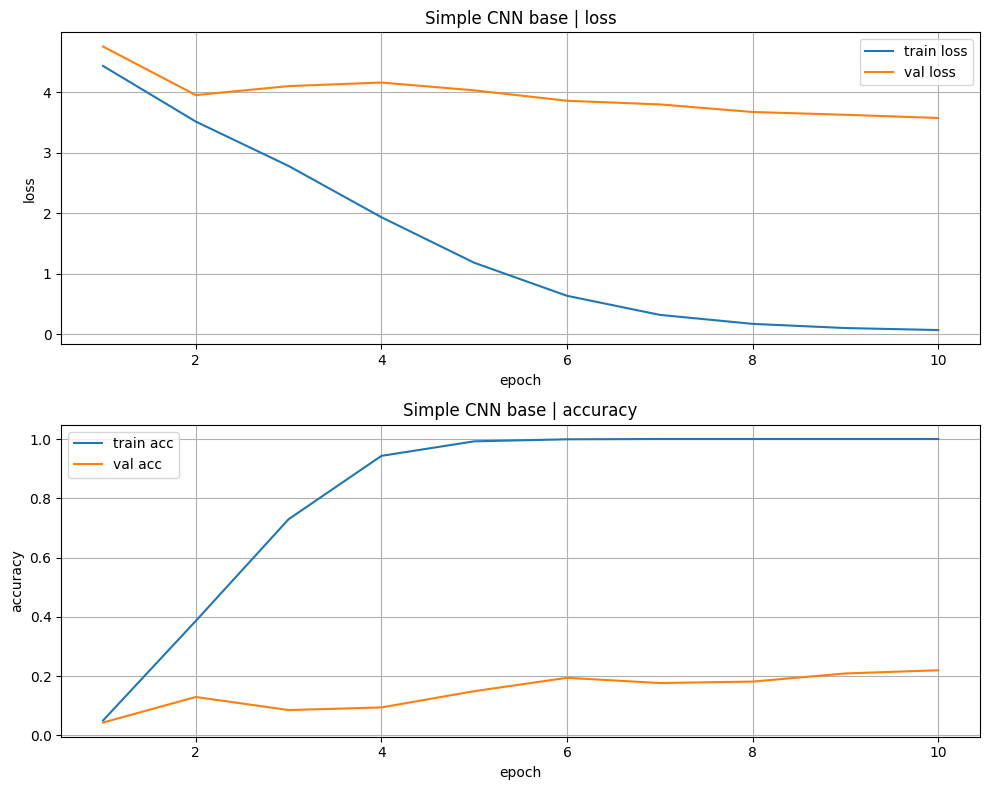

In [39]:
model = SimpleCNN(NUM_CLASSES).to(DEVICE)
res_c1 = run_experiment("C1", model, train_base_loader, val_loader, lr=1e-3, epochs=10)
plot_history(res_c1["history"], title="Simple CNN base")

#### C2

Experiment: C2
Trainable params: 25810342
Epoch 01/10 | train loss 4.4024, acc 0.053 | val loss 4.7859, acc 0.047 | 11.4s
Epoch 02/10 | train loss 3.7717, acc 0.199 | val loss 3.8486, acc 0.121 | 11.4s
Epoch 03/10 | train loss 3.3672, acc 0.315 | val loss 3.6057, acc 0.161 | 10.3s
Epoch 04/10 | train loss 3.0518, acc 0.393 | val loss 3.4154, acc 0.238 | 11.1s
Epoch 05/10 | train loss 2.7252, acc 0.520 | val loss 3.2135, acc 0.280 | 11.4s
Epoch 06/10 | train loss 2.4356, acc 0.597 | val loss 3.2464, acc 0.275 | 11.3s
Epoch 07/10 | train loss 2.1834, acc 0.661 | val loss 3.1979, acc 0.265 | 11.1s
Epoch 08/10 | train loss 1.9207, acc 0.721 | val loss 2.9761, acc 0.331 | 11.5s
Epoch 09/10 | train loss 1.7110, acc 0.758 | val loss 2.8904, acc 0.345 | 11.2s
Epoch 10/10 | train loss 1.4815, acc 0.820 | val loss 2.8498, acc 0.328 | 10.2s


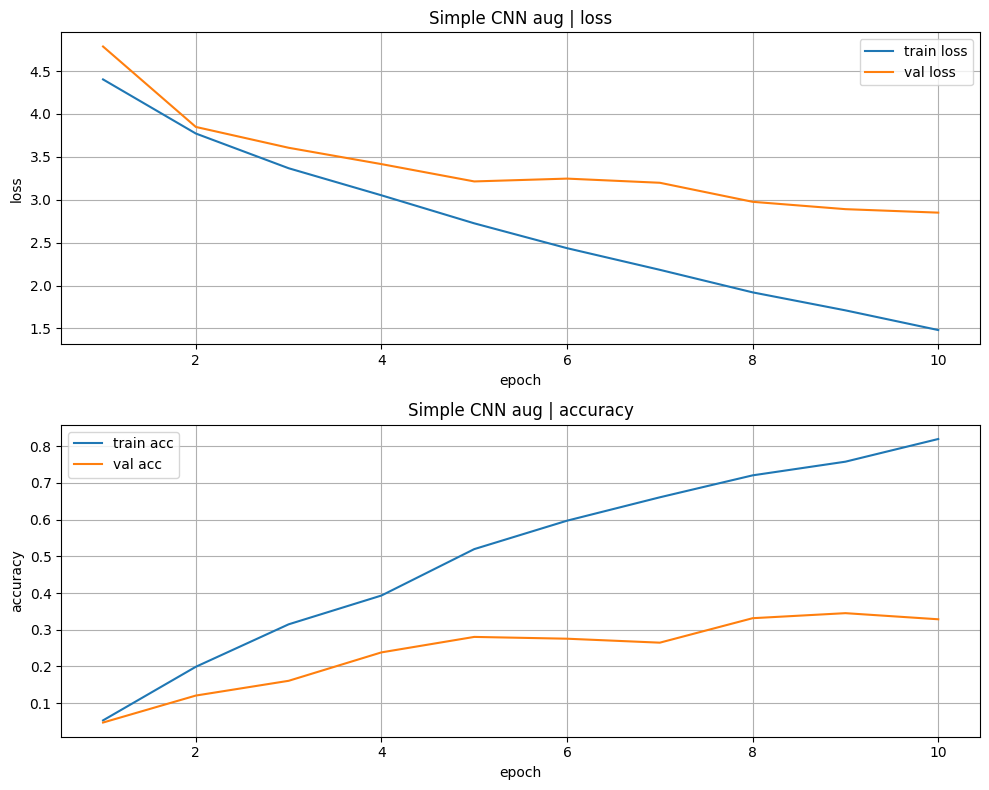

In [40]:
model = SimpleCNN(NUM_CLASSES).to(DEVICE)
res_c2 = run_experiment("C2", model, train_aug_loader, val_loader, lr=1e-3, epochs=10)
plot_history(res_c2["history"], title="Simple CNN aug")

#### C3

In [41]:
def set_requires_grad(model: nn.Module, flag: bool) -> None:
    for p in model.parameters():
        p.requires_grad = flag

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


Experiment: C3
Trainable params: 52326
Epoch 01/10 | train loss 4.7231, acc 0.021 | val loss 4.4032, acc 0.058 | 10.4s
Epoch 02/10 | train loss 4.1488, acc 0.113 | val loss 4.0410, acc 0.161 | 11.1s
Epoch 03/10 | train loss 3.7020, acc 0.311 | val loss 3.6553, acc 0.325 | 11.0s
Epoch 04/10 | train loss 3.2865, acc 0.517 | val loss 3.3441, acc 0.409 | 11.0s
Epoch 05/10 | train loss 2.8774, acc 0.652 | val loss 3.0412, acc 0.490 | 11.1s
Epoch 06/10 | train loss 2.5619, acc 0.754 | val loss 2.7734, acc 0.569 | 10.3s
Epoch 07/10 | train loss 2.2543, acc 0.801 | val loss 2.5531, acc 0.614 | 10.4s
Epoch 08/10 | train loss 1.9966, acc 0.836 | val loss 2.3650, acc 0.619 | 10.9s
Epoch 09/10 | train loss 1.7783, acc 0.845 | val loss 2.1981, acc 0.662 | 11.0s
Epoch 10/10 | train loss 1.5556, acc 0.886 | val loss 2.0386, acc 0.689 | 11.0s


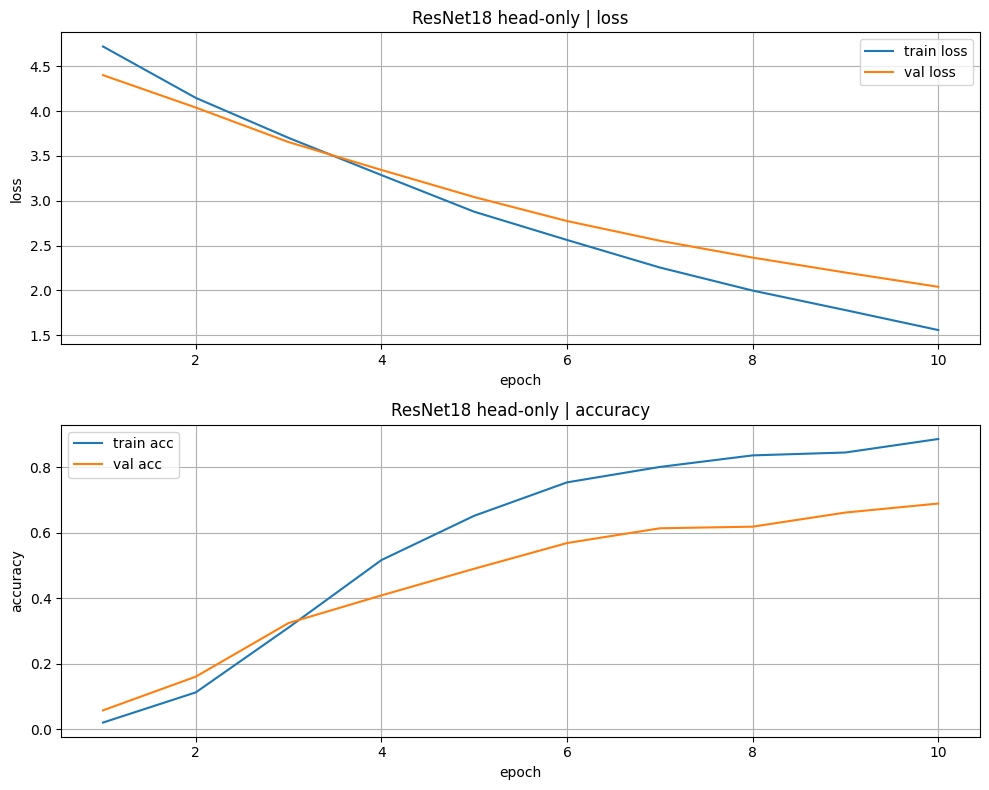

In [42]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

set_requires_grad(model, False)
set_requires_grad(model.fc, True)

params = model.fc.parameters()

res_c3 = run_experiment("C3", model, train_aug_loader, val_loader, lr=1e-3, epochs=10, params=params)
plot_history(res_c3["history"], title="ResNet18 head-only")

#### C4

Experiment: C4
Trainable params: 8446054
Epoch 01/10 | train loss 3.6577, acc 0.240 | val loss 1.9316, acc 0.551 | 11.4s
Epoch 02/10 | train loss 1.3433, acc 0.846 | val loss 1.0237, acc 0.766 | 10.6s
Epoch 03/10 | train loss 0.5039, acc 0.964 | val loss 0.7156, acc 0.850 | 10.4s
Epoch 04/10 | train loss 0.1830, acc 0.992 | val loss 0.6700, acc 0.855 | 11.3s
Epoch 05/10 | train loss 0.0773, acc 0.999 | val loss 0.6568, acc 0.872 | 11.1s
Epoch 06/10 | train loss 0.0409, acc 1.000 | val loss 0.6063, acc 0.882 | 10.9s
Epoch 07/10 | train loss 0.0236, acc 1.000 | val loss 0.5527, acc 0.886 | 11.2s
Epoch 08/10 | train loss 0.0149, acc 1.000 | val loss 0.5285, acc 0.890 | 10.2s
Epoch 09/10 | train loss 0.0116, acc 1.000 | val loss 0.4966, acc 0.897 | 10.5s
Epoch 10/10 | train loss 0.0087, acc 1.000 | val loss 0.4884, acc 0.893 | 11.1s


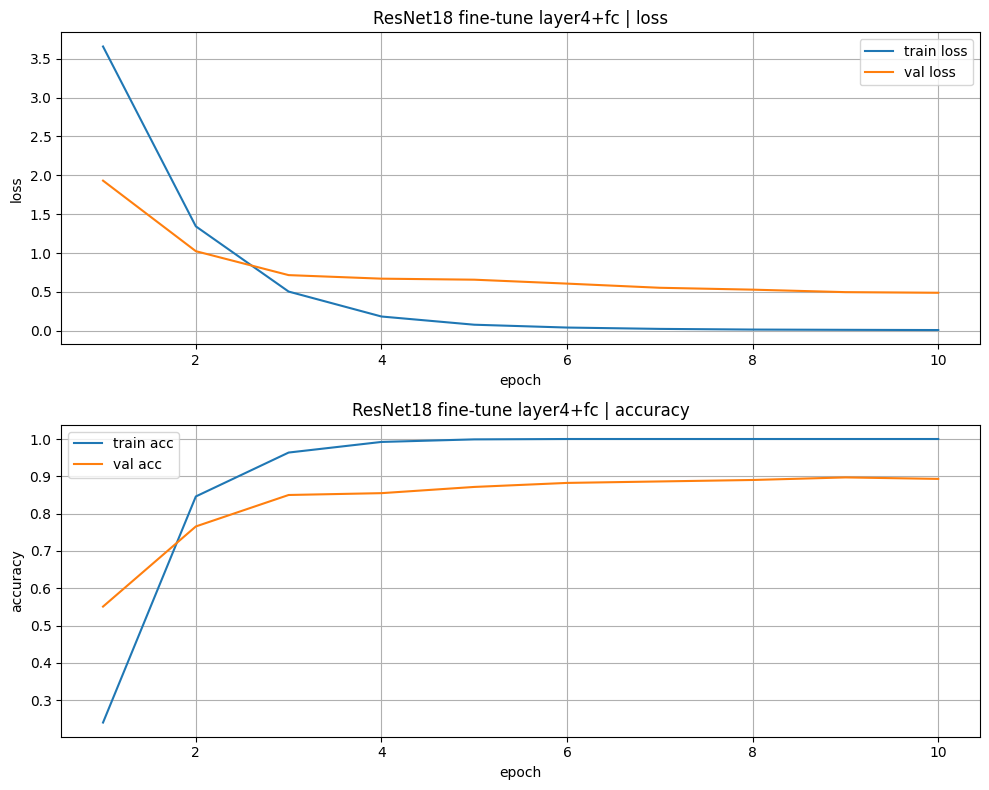

In [43]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

set_requires_grad(model, False)
set_requires_grad(model.layer4, True)
set_requires_grad(model.fc, True)

params = [
    {"params": model.layer4.parameters()},
    {"params": model.fc.parameters()},
]

res_c4 = run_experiment("C4", model, train_aug_loader, val_loader, lr=1e-3, epochs=10, params=params)
plot_history(res_c4["history"], title="ResNet18 fine-tune layer4+fc")

#### Лучший результат

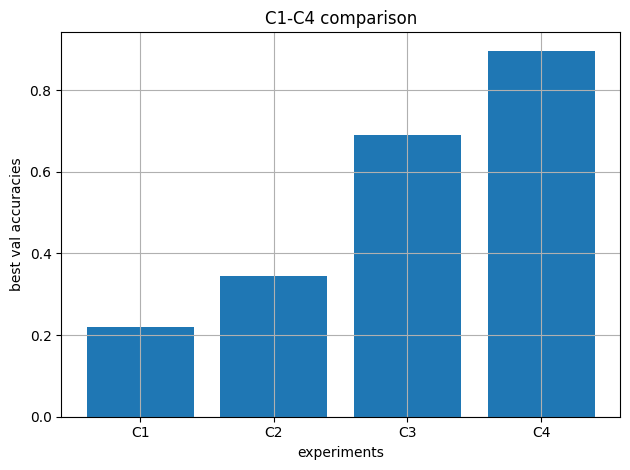

In [44]:
exp_results_a = [res_c1, res_c2, res_c3, res_c4]
experiments_id = ["C1", "C2", "C3", "C4"]
best_val_accuracies = [exp["best_val_acc"] for exp in exp_results_a]

plt.bar(experiments_id, best_val_accuracies)
plt.xlabel("experiments")
plt.ylabel("best val accuracies")
plt.title("C1-C4 comparison")
plt.grid(True)
plt.savefig("artifacts/figures/classification_compare.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

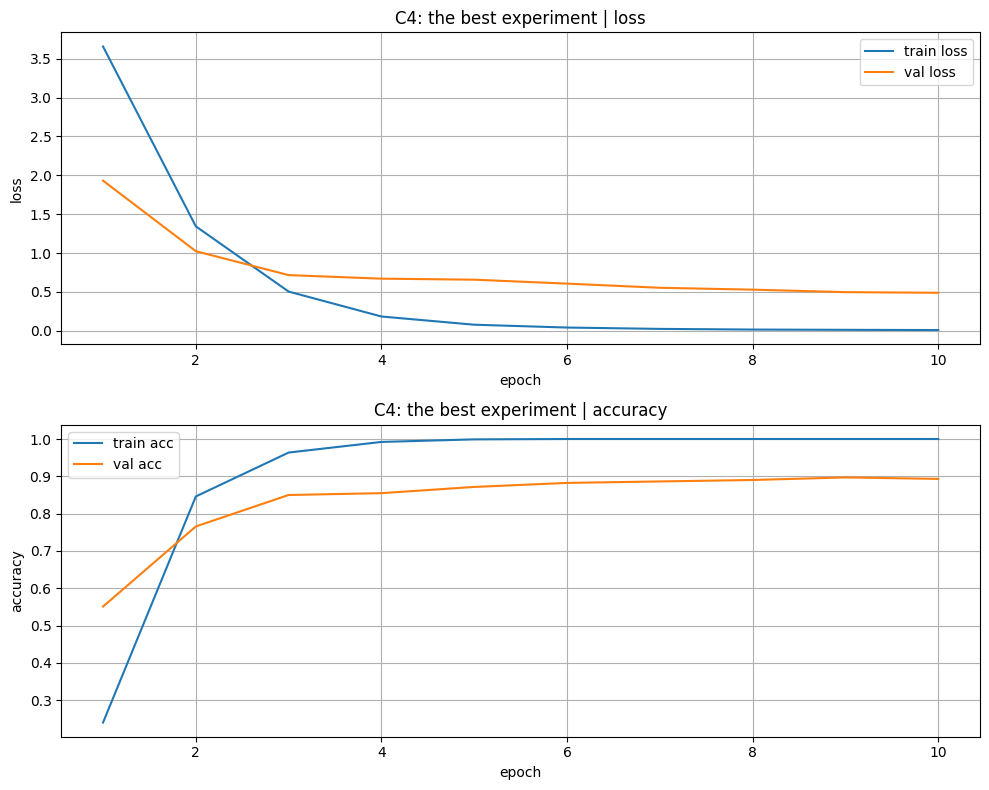

In [45]:
best_res = exp_results_a[best_val_accuracies.index(max(best_val_accuracies))]
plot_history(best_res["history"], title=f"{best_res["exp_id"]}: the best experiment",
             filepath="artifacts/figures/classification_curves_best.png")

In [46]:
best_model = best_res["model"]
tmp_path = "artifacts/best_classifier.pt"
torch.save(best_model.state_dict(), tmp_path)
print("Saved to", tmp_path)

Saved to artifacts/best_classifier.pt


In [47]:
best_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [50]:
best_config = {
    "dataset": "Flowers102",
    "seed": SEED,
    "model_architecture": [str(best_model.net[i]) for i in range(len(best_model.net))] if best_res["exp_id"] not in ("C3", "C4") else "ResNet18",
    "transforms": [str(t) for t in best_res["transforms"]],
    "optimizer": "Adam",
    "lr": best_res["lr"],
    "epochs": best_res["epochs"],
}

with open("artifacts/best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

In [51]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion)
print("Test accuracy:", round(test_acc, 3))

Test accuracy: 0.874


### Часть B: детекция

In [52]:
model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
model.eval()
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 185MB/s]


#### V1

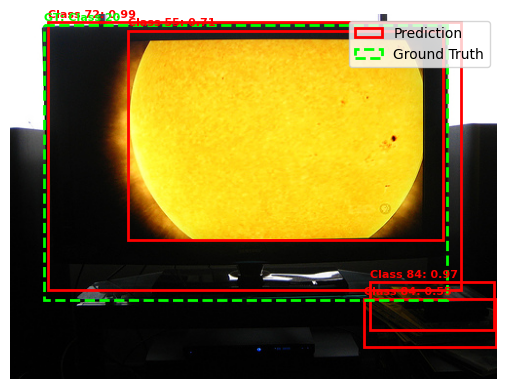

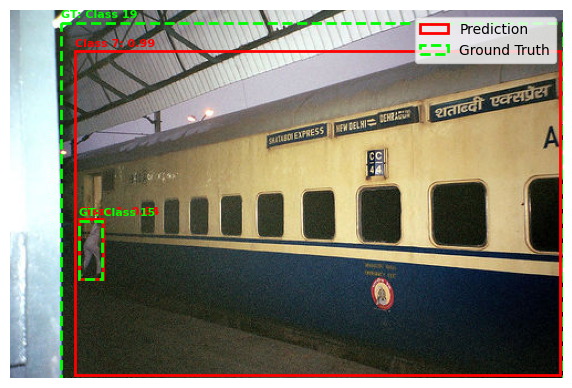

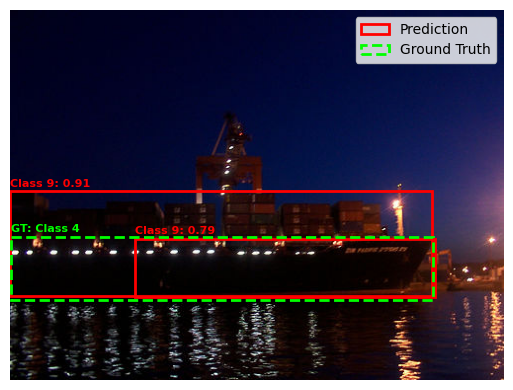

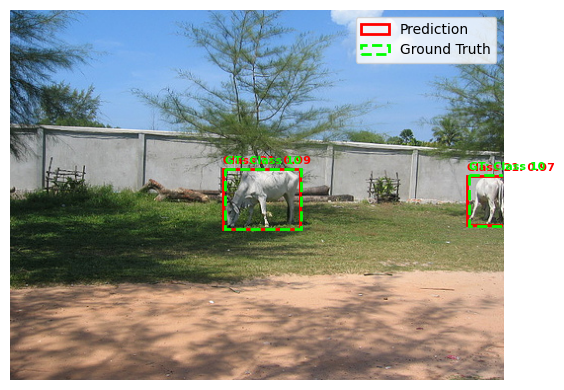

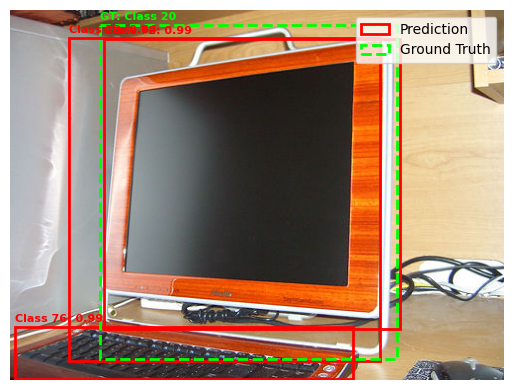

In [80]:
metrics_v1 = run_evaluation(score_threshold=0.3, num_images=len(voc_dataset), num_images_display=5)

In [81]:
print(f"Precision@IoU: {metrics_v1["precision"]:.3f}")
print(f"Recall@IoU: {metrics_v1["recall"]:.3f}")
print(f"F1@IoU: {metrics_v1["f1"]:.3f}")
print(f"Mean IoU (matched): {metrics_v1["mean_iou"]:.3f}")

Precision@IoU: 0.173
Recall@IoU: 0.508
F1@IoU: 0.258
Mean IoU (matched): 0.858


#### V2

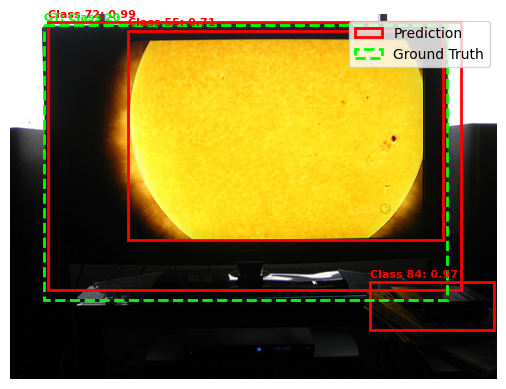

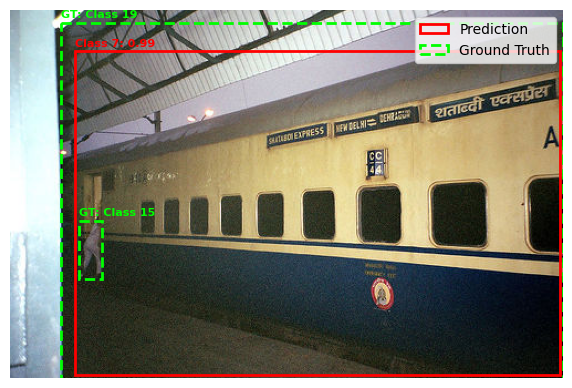

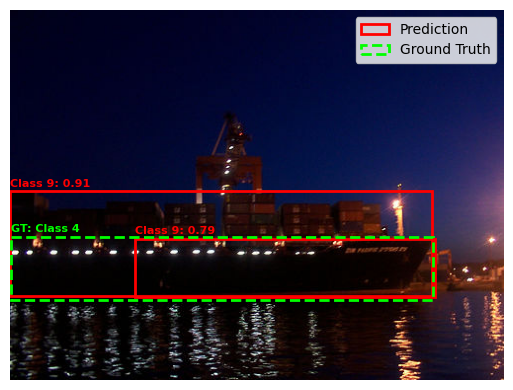

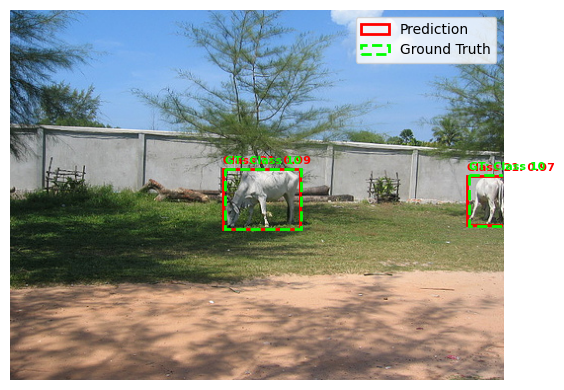

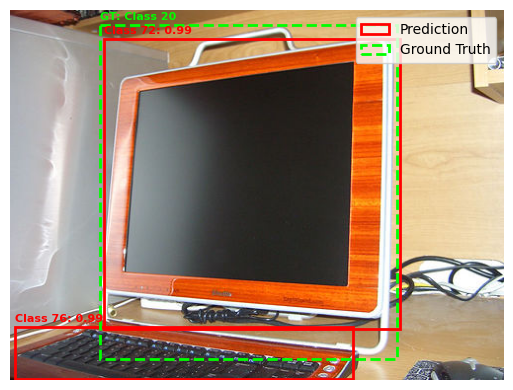

In [82]:
metrics_v2 = run_evaluation(score_threshold=0.7, num_images=len(voc_dataset), num_images_display=5)

In [83]:
print(f"Precision@IoU: {metrics_v2["precision"]:.3f}")
print(f"Recall@IoU: {metrics_v2["recall"]:.3f}")
print(f"F1@IoU: {metrics_v2["f1"]:.3f}")
print(f"Mean IoU (matched): {metrics_v2["mean_iou"]:.3f}")

Precision@IoU: 0.322
Recall@IoU: 0.486
F1@IoU: 0.388
Mean IoU (matched): 0.862


#### Результаты

In [84]:
def plot_metrics_comparison(metrics_by_threshold):
    thresholds = sorted(metrics_by_threshold.keys())
    metric_names = list(metrics_by_threshold[thresholds[0]].keys())

    n_metrics = len(metric_names)
    n_thresholds = len(thresholds)

    fig, ax = plt.subplots(figsize=(10, 6))

    bar_width = 0.35
    x_positions = np.arange(n_metrics)

    for i, threshold in enumerate(thresholds):
        values = [metrics_by_threshold[threshold][metric] for metric in metric_names]
        offset = (i - n_thresholds/2 + 0.5) * bar_width
        ax.bar(x_positions + offset, values, bar_width,
               label=f'score_threshold = {threshold}', alpha=0.8)

    ax.set_xlabel("metrics")
    ax.set_ylabel("scores")
    ax.set_title("Metrics comparison")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    for i, threshold in enumerate(thresholds):
        values = [metrics_by_threshold[threshold][metric] for metric in metric_names]
        offset = (i - n_thresholds/2 + 0.5) * bar_width
        for j, value in enumerate(values):
            ax.text(x_positions[j] + offset, value + 0.02,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=9)

    plt.savefig("artifacts/figures/detection_metrics.png", dpi=150, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

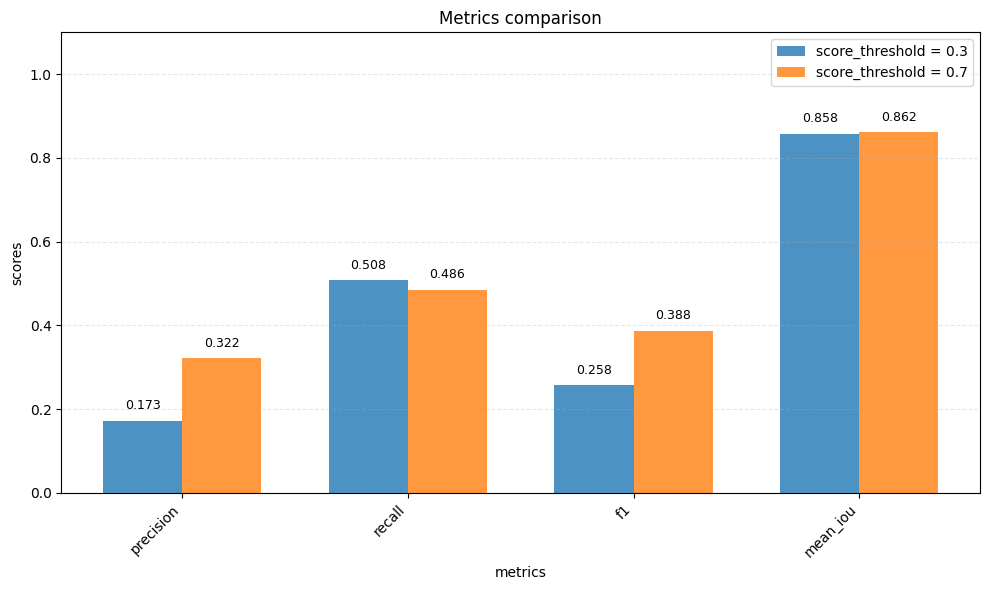

In [85]:
metrics_by_threshold = {
    0.3: {
        "precision": metrics_v1["precision"],
        "recall": metrics_v1["recall"],
        "f1": metrics_v1["f1"],
        "mean_iou": metrics_v1["mean_iou"],
        },
    0.7: {
        "precision": metrics_v2["precision"],
        "recall": metrics_v2["recall"],
        "f1": metrics_v2["f1"],
        "mean_iou": metrics_v2["mean_iou"],
        },
}

plot_metrics_comparison(metrics_by_threshold)

### Сохранение runs.csv

In [86]:
df1 = pd.DataFrame(exp_results_a, columns=["exp_id", "lr", "epochs", "best_val_acc"])

df1 = df1.rename(columns={
    "exp_id": "experiment_id",
    "epochs": "epochs_trained",
    "best_val_acc": "best_val_accuracy"
    })

df1["task"] = "classification"
df1["dataset"] = "Flowers102"
df1["seed"] = SEED
df1["optimizer"] = "Adam"
df1["test_accuracy"] = np.where(df1["experiment_id"] == best_res["exp_id"], test_acc, np.nan)

df1

,experiment_id,lr,epochs_trained,best_val_accuracy,task,dataset,seed,optimizer,test_accuracy
0,C1,0.001,10,0.219608,classification,Flowers102,42,Adam,NaN
1,C2,0.001,10,0.345098,classification,Flowers102,42,Adam,NaN
2,C3,0.001,10,0.689216,classification,Flowers102,42,Adam,NaN
3,C4,0.001,10,0.897059,classification,Flowers102,42,Adam,0.874126


In [87]:
res_v1 = {
    "experiment_id": "V1",
    "precision": metrics_v1["precision"],
    "recall": metrics_v1["recall"],
    "f1": metrics_v1["f1"],
    "mean_iou": metrics_v1["mean_iou"],
}

res_v2 = {
    "experiment_id": "V2",
    "precision": metrics_v2["precision"],
    "recall": metrics_v2["recall"],
    "f1": metrics_v2["f1"],
    "mean_iou": metrics_v2["mean_iou"],
}

exp_results_b = [res_v1, res_v2]

df2 = pd.DataFrame(exp_results_b)

df2["task"] = "detection"
df2["dataset"] = "VOCDetection"

df2

,experiment_id,precision,recall,f1,mean_iou,task,dataset
0,V1,0.172750,0.507570,0.257769,0.857793,detection,VOCDetection
1,V2,0.322282,0.485843,0.387511,0.861867,detection,VOCDetection


In [88]:
df = pd.concat([df1, df2], ignore_index=True, sort=False)

df["model_summary"] = ""
df["notes"] = ""

df.loc[df["experiment_id"] == "C1", "model_summary"] = "Simple CNN"
df.loc[df["experiment_id"] == "C2", "model_summary"] = "Simple CNN"
df.loc[df["experiment_id"] == "C3", "model_summary"] = "ResNet18 with pretrained weights (fine-tune head-only)"
df.loc[df["experiment_id"] == "C4", "model_summary"] = "ResNet18 with pretrained weights (fine-tune layer4+fc)"
df.loc[df["experiment_id"] == "V1", "model_summary"] = "FasterRCNN_ResNet50_FPN_V2 with pretrained weights"
df.loc[df["experiment_id"] == "V2", "model_summary"] = "FasterRCNN_ResNet50_FPN_V2 with pretrained weights"

df.loc[df["experiment_id"] == "C1", "notes"] = "training without augmentations"
df.loc[df["experiment_id"] == "C2", "notes"] = "training with augmentations"
df.loc[df["experiment_id"] == "C3", "notes"] = "training with augmentations"
df.loc[df["experiment_id"] == "C4", "notes"] = "training with augmentations"
df.loc[df["experiment_id"] == "V1", "notes"] = "inference at score_threshold = 0.3"
df.loc[df["experiment_id"] == "V2", "notes"] = "inference at score_threshold = 0.7"

df

,experiment_id,lr,epochs_trained,best_val_accuracy,task,dataset,seed,optimizer,test_accuracy,precision,recall,f1,mean_iou,model_summary,notes
0,C1,0.001,10.0,0.219608,classification,Flowers102,42.0,Adam,NaN,NaN,NaN,NaN,NaN,Simple CNN,training without augmentations
1,C2,0.001,10.0,0.345098,classification,Flowers102,42.0,Adam,NaN,NaN,NaN,NaN,NaN,Simple CNN,training with augmentations
2,C3,0.001,10.0,0.689216,classification,Flowers102,42.0,Adam,NaN,NaN,NaN,NaN,NaN,ResNet18 with pretrained weights (fine-tune he...,training with augmentations
3,C4,0.001,10.0,0.897059,classification,Flowers102,42.0,Adam,0.874126,NaN,NaN,NaN,NaN,ResNet18 with pretrained weights (fine-tune la...,training with augmentations
4,V1,NaN,NaN,NaN,detection,VOCDetection,NaN,NaN,NaN,0.172750,0.507570,0.257769,0.857793,FasterRCNN_ResNet50_FPN_V2 with pretrained wei...,inference at score_threshold = 0.3
5,V2,NaN,NaN,NaN,detection,VOCDetection,NaN,NaN,NaN,0.322282,0.485843,0.387511,0.861867,FasterRCNN_ResNet50_FPN_V2 with pretrained wei...,inference at score_threshold = 0.7


In [89]:
df.to_csv("artifacts/runs.csv", na_rep="", index=False)